In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

### Defining Path
- Sources
-  Output

In [2]:
%pwd

'/path/to/project'

In [3]:
# resource data
data_sources = Path("../../data/M5")
# output data
data_output = Path("data/data_output")
data_output.mkdir(exist_ok=True)


In [4]:
sales_data = data_sources / "sales_train_evaluation.csv"
calendar_and_promos_data = data_sources / "calendar.csv"
price_data = data_sources / "sell_prices.csv"

In [5]:
sales_dtypes = {
    "id": "category",
    "item_id": "category",
    "dept_id": "category",
    "cat_id": "category",
    "store_id": "category",
    "state_id": "category",
    **{f"d_{i}": np.uint64 for i in range(1942)},
}

df = pd.read_csv(sales_data, dtype=sales_dtypes)
df.head(5)


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,1,0,4,0,1,3,0,2,6
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,2,1,0,0,2,1,0


In [104]:
cal_dtypes = {
    "d": "category",
    "wm_yr_wk": np.uint16,
    "event_name_1": "category",
    "event_type_1": "category",
    "event_name_2": "category",
    "event_type_2": "category",
    "snap_CA": np.uint8,
    "snap_TX": np.uint8,
    "snap_WI": np.uint8,
}
df_cal = pd.read_csv(calendar_and_promos_data, dtype=cal_dtypes, parse_dates=["date"])

df_cal.head()
# df_cal.info()

,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0
3,2011-02-01,11101,Tuesday,4,2,2011,d_4,NaN,NaN,NaN,NaN,1,1,0
4,2011-02-02,11101,Wednesday,5,2,2011,d_5,NaN,NaN,NaN,NaN,1,0,1


In [105]:
for event_col in df_cal.filter(like="event").columns:
    df_cal[event_col] = df_cal[event_col].cat.add_categories("no_event").fillna("no_event")

In [106]:
price_dtypes = {
    "store_id": "category",
    "item_id": "category",
    "wm_yr_wk": np.uint16,
    "sell_price": np.float64,
}
df_price = pd.read_csv(price_data, dtype=price_dtypes)

df_price.head()

,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26
3,CA_1,HOBBIES_1_001,11328,8.26
4,CA_1,HOBBIES_1_001,11329,8.26


In [107]:
df_sales = df.melt(
    id_vars=["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"],
    var_name="d",
    value_name="y", # `y` is the number of units sold on a given day
)

df_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,y
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
3,HOBBIES_1_004_CA_1_evaluation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0
4,HOBBIES_1_005_CA_1_evaluation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,d_1,0


### Join 3 Files

In [108]:
df_sales = df_sales.merge(
    right=df_cal[
        [
            "d",
            "date",
            "wm_yr_wk",
            "event_name_1",
            "event_type_1",
            "event_name_2",
            "event_type_2",
            "snap_CA",
            "snap_TX",
            "snap_WI",
        ]
    ],
    on="d",
)

In [109]:
df_sales = df_sales.merge(right=df_price, on=["store_id", "item_id", "wm_yr_wk"])


In [110]:
df_sales =(
          df_sales.sort_values(by=["id", "date"])  # Sort by time series id and date.
                   .drop(columns=["wm_yr_wk"])  # Drop columns that are no longer needed.
          )

In [111]:
df_sales.head(10)


,id,item_id,dept_id,cat_id,store_id,state_id,d,y,date,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
16838178,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_897,0,2013-07-13,no_event,no_event,no_event,no_event,0,1,0,9.58
16838179,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_898,0,2013-07-14,no_event,no_event,no_event,no_event,0,0,1,9.58
16838180,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_899,0,2013-07-15,no_event,no_event,no_event,no_event,0,1,1,9.58
16838181,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_900,0,2013-07-16,no_event,no_event,no_event,no_event,0,0,0,9.58
16838182,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_901,0,2013-07-17,no_event,no_event,no_event,no_event,0,0,0,9.58
16838183,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_902,1,2013-07-18,no_event,no_event,no_event,no_event,0,0,0,9.58
16838184,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_903,0,2013-07-19,no_event,no_event,no_event,no_event,0,0,0,9.58
17010595,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_904,0,2013-07-20,no_event,no_event,no_event,no_event,0,0,0,9.58
17010596,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_905,0,2013-07-21,no_event,no_event,no_event,no_event,0,0,0,9.58
17010597,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,d_906,0,2013-07-22,no_event,no_event,no_event,no_event,0,0,0,9.58


In [112]:
df_sales["d"]=df_sales["d"].apply(lambda x: int(x.split("_")[1]))

In [113]:
df_sales.tail(10)


,id,item_id,dept_id,cat_id,store_id,state_id,d,y,date,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,sell_price
46607266,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1932,1,2016-05-13,no_event,no_event,no_event,no_event,0,1,0,1.0
46820690,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1933,2,2016-05-14,no_event,no_event,no_event,no_event,0,0,1,1.0
46820691,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1934,0,2016-05-15,no_event,no_event,no_event,no_event,0,1,1,1.0
46820692,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1935,5,2016-05-16,no_event,no_event,no_event,no_event,0,0,0,1.0
46820693,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1936,4,2016-05-17,no_event,no_event,no_event,no_event,0,0,0,1.0
46820694,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1937,0,2016-05-18,no_event,no_event,no_event,no_event,0,0,0,1.0
46820695,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1938,2,2016-05-19,no_event,no_event,no_event,no_event,0,0,0,1.0
46820696,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1939,2,2016-05-20,no_event,no_event,no_event,no_event,0,0,0,1.0
46881675,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1940,5,2016-05-21,no_event,no_event,no_event,no_event,0,0,0,1.0
46881676,FOODS_3_827_WI_3_evaluation,FOODS_3_827,FOODS_3,FOODS,WI_3,WI,1941,1,2016-05-22,no_event,no_event,no_event,no_event,0,0,0,1.0


In [114]:
# reduce memory
def reduce_mem_usage(df, verbose=True):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024**2    
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)    
    end_mem = df.memory_usage().sum() / 1024**2
    if verbose: print('Mem. usage decreased to {:5.2f} Mb ({:.1f}% reduction)'.format(end_mem, 100 * (start_mem - end_mem) / start_mem))

In [115]:
reduce_mem_usage(df_sales)

Mem. usage decreased to 1923.85 Mb (21.8% reduction)


## Feature Engineering

In [116]:
# create lags, rolling lags, mean, and std
# Referenced : https://www.kaggle.com/code/anshuls235/time-series-forecasting-eda-fe-modelling#6.-Modelling-and-Prediction
# Introduce lags
lags = [1,2,3,6,12,24,36]
for lag in lags:
    df_sales['sold_lag_'+str(lag)] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'],as_index=False)['y'].shift(lag).astype(np.float16)

In [117]:
df_sales.head()

,id,item_id,dept_id,cat_id,store_id,state_id,d,y,date,event_name_1,...,snap_TX,snap_WI,sell_price,sold_lag_1,sold_lag_2,sold_lag_3,sold_lag_6,sold_lag_12,sold_lag_24,sold_lag_36
16838178,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,897,0,2013-07-13,no_event,...,1,0,9.578125,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16838179,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,898,0,2013-07-14,no_event,...,0,1,9.578125,0.0,NaN,NaN,NaN,NaN,NaN,NaN
16838180,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,899,0,2013-07-15,no_event,...,1,1,9.578125,0.0,0.0,NaN,NaN,NaN,NaN,NaN
16838181,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,900,0,2013-07-16,no_event,...,0,0,9.578125,0.0,0.0,0.0,NaN,NaN,NaN,NaN
16838182,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,901,0,2013-07-17,no_event,...,0,0,9.578125,0.0,0.0,0.0,NaN,NaN,NaN,NaN


In [118]:
# try to figure out this
df_sales.isnull().sum()

id                    0
item_id               0
dept_id               0
cat_id                0
store_id              0
state_id              0
d                     0
y                     0
date                  0
event_name_1          0
event_type_1          0
event_name_2          0
event_type_2          0
snap_CA               0
snap_TX               0
snap_WI               0
sell_price            0
sold_lag_1        30490
sold_lag_2        60980
sold_lag_3        91470
sold_lag_6       182940
sold_lag_12      365880
sold_lag_24      731760
sold_lag_36     1097640
dtype: int64

In [119]:
df_sales['iteam_sold_avg'] = df_sales.groupby('item_id')['y'].transform('mean').astype(np.float16)
df_sales['state_sold_avg'] = df_sales.groupby('state_id')['y'].transform('mean').astype(np.float16)
df_sales['store_sold_avg'] = df_sales.groupby('store_id')['y'].transform('mean').astype(np.float16)
df_sales['cat_sold_avg'] = df_sales.groupby('cat_id')['y'].transform('mean').astype(np.float16)
df_sales['dept_sold_avg'] = df_sales.groupby('dept_id')['y'].transform('mean').astype(np.float16)
df_sales['cat_dept_sold_avg'] = df_sales.groupby(['cat_id','dept_id'])['y'].transform('mean').astype(np.float16)
df_sales['store_item_sold_avg'] = df_sales.groupby(['store_id','item_id'])['y'].transform('mean').astype(np.float16)
df_sales['cat_item_sold_avg'] = df_sales.groupby(['cat_id','item_id'])['y'].transform('mean').astype(np.float16)
df_sales['dept_item_sold_avg'] = df_sales.groupby(['dept_id','item_id'])['y'].transform('mean').astype(np.float16)
df_sales['state_store_sold_avg'] = df_sales.groupby(['state_id','store_id'])['y'].transform('mean').astype(np.float16)
df_sales['state_store_cat_sold_avg'] = df_sales.groupby(['state_id','store_id','cat_id'])['y'].transform('mean').astype(np.float16)
df_sales['store_cat_dept_sold_avg'] = df_sales.groupby(['store_id','cat_id','dept_id'])['y'].transform('mean').astype(np.float16)

In [120]:
df_sales['rolling_sold_mean'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['y'].transform(lambda x: x.rolling(window=7).mean()).astype(np.float16)

In [121]:
df_sales['expanding_sold_mean'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['y'].transform(lambda x: x.expanding(2).mean()).astype(np.float16)

In [122]:
# df_sales['daily_avg_sold'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id','d'])['sold'].transform('mean').astype(np.float16)
# df_sales['avg_sold'] = df_sales.groupby(['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id'])['sold'].transform('mean').astype(np.float16)
# df_sales['selling_trend'] = (df_sales['daily_avg_sold'] - df_sales['avg_sold']).astype(np.float16)
# df_sales.drop(['daily_avg_sold','avg_sold'],axis=1,inplace=True)

In [123]:
# delete data that is > 36 days
df_sales = df_sales[df_sales['d'] > 36]

In [149]:
df_sales

(46439537, 34)

In [154]:
df_sales.iloc[16838182]

id                          FOODS_2_216_CA_4_evaluation
item_id                                     FOODS_2_216
d                                                  1827
y                                                     1
date                                2016-01-29 00:00:00
event_name_1                                   no_event
event_type_1                                   no_event
event_name_2                                   no_event
event_type_2                                   no_event
snap_CA                                               0
snap_TX                                               0
snap_WI                                               0
sell_price                                     5.980469
sold_lag_1                                          2.0
sold_lag_2                                          0.0
sold_lag_3                                          0.0
sold_lag_6                                          1.0
sold_lag_12                                     


## Save Data

In [134]:

import gc
df_sales = df_sales.drop(['dept_id', 'cat_id', 'store_id', 'state_id'], axis=1)
df_sales.to_pickle('data/data_output/preprocessed_data.pkl')
# del df_sales
gc.collect();

## Final Data
- choose id to create training data
- 'd' and 'date' choose one to delete
- y = target value
- lag values contains lot of Nan, still try to figure out how to deal with it

In [135]:
# Read data named preprocessed_data
data = pd.read_pickle('data/data_output/preprocessed_data.pkl')


In [136]:
data

,id,item_id,d,y,date,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,...,dept_sold_avg,cat_dept_sold_avg,store_item_sold_avg,cat_item_sold_avg,dept_item_sold_avg,state_store_sold_avg,state_store_cat_sold_avg,store_cat_dept_sold_avg,rolling_sold_mean,expanding_sold_mean
16838178,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,897,0,2013-07-13,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,NaN
16838179,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,898,0,2013-07-14,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.000000
16838180,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,899,0,2013-07-15,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.000000
16838181,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,900,0,2013-07-16,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.000000
16838182,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,901,0,2013-07-17,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
46820694,FOODS_3_827_WI_3_evaluation,FOODS_3_827,1937,0,2016-05-18,no_event,no_event,no_event,no_event,0,...,2.619141,2.619141,1.675781,1.726562,1.726562,1.371094,2.136719,2.826172,1.713867,1.671875
46820695,FOODS_3_827_WI_3_evaluation,FOODS_3_827,1938,2,2016-05-19,no_event,no_event,no_event,no_event,0,...,2.619141,2.619141,1.675781,1.726562,1.726562,1.371094,2.136719,2.826172,2.000000,1.671875
46820696,FOODS_3_827_WI_3_evaluation,FOODS_3_827,1939,2,2016-05-20,no_event,no_event,no_event,no_event,0,...,2.619141,2.619141,1.675781,1.726562,1.726562,1.371094,2.136719,2.826172,2.142578,1.672852
46881675,FOODS_3_827_WI_3_evaluation,FOODS_3_827,1940,5,2016-05-21,no_event,no_event,no_event,no_event,0,...,2.619141,2.619141,1.675781,1.726562,1.726562,1.371094,2.136719,2.826172,2.572266,1.676758


In [137]:
data['id'].unique()[1000]

'HOUSEHOLD_1_445_CA_1_evaluation'

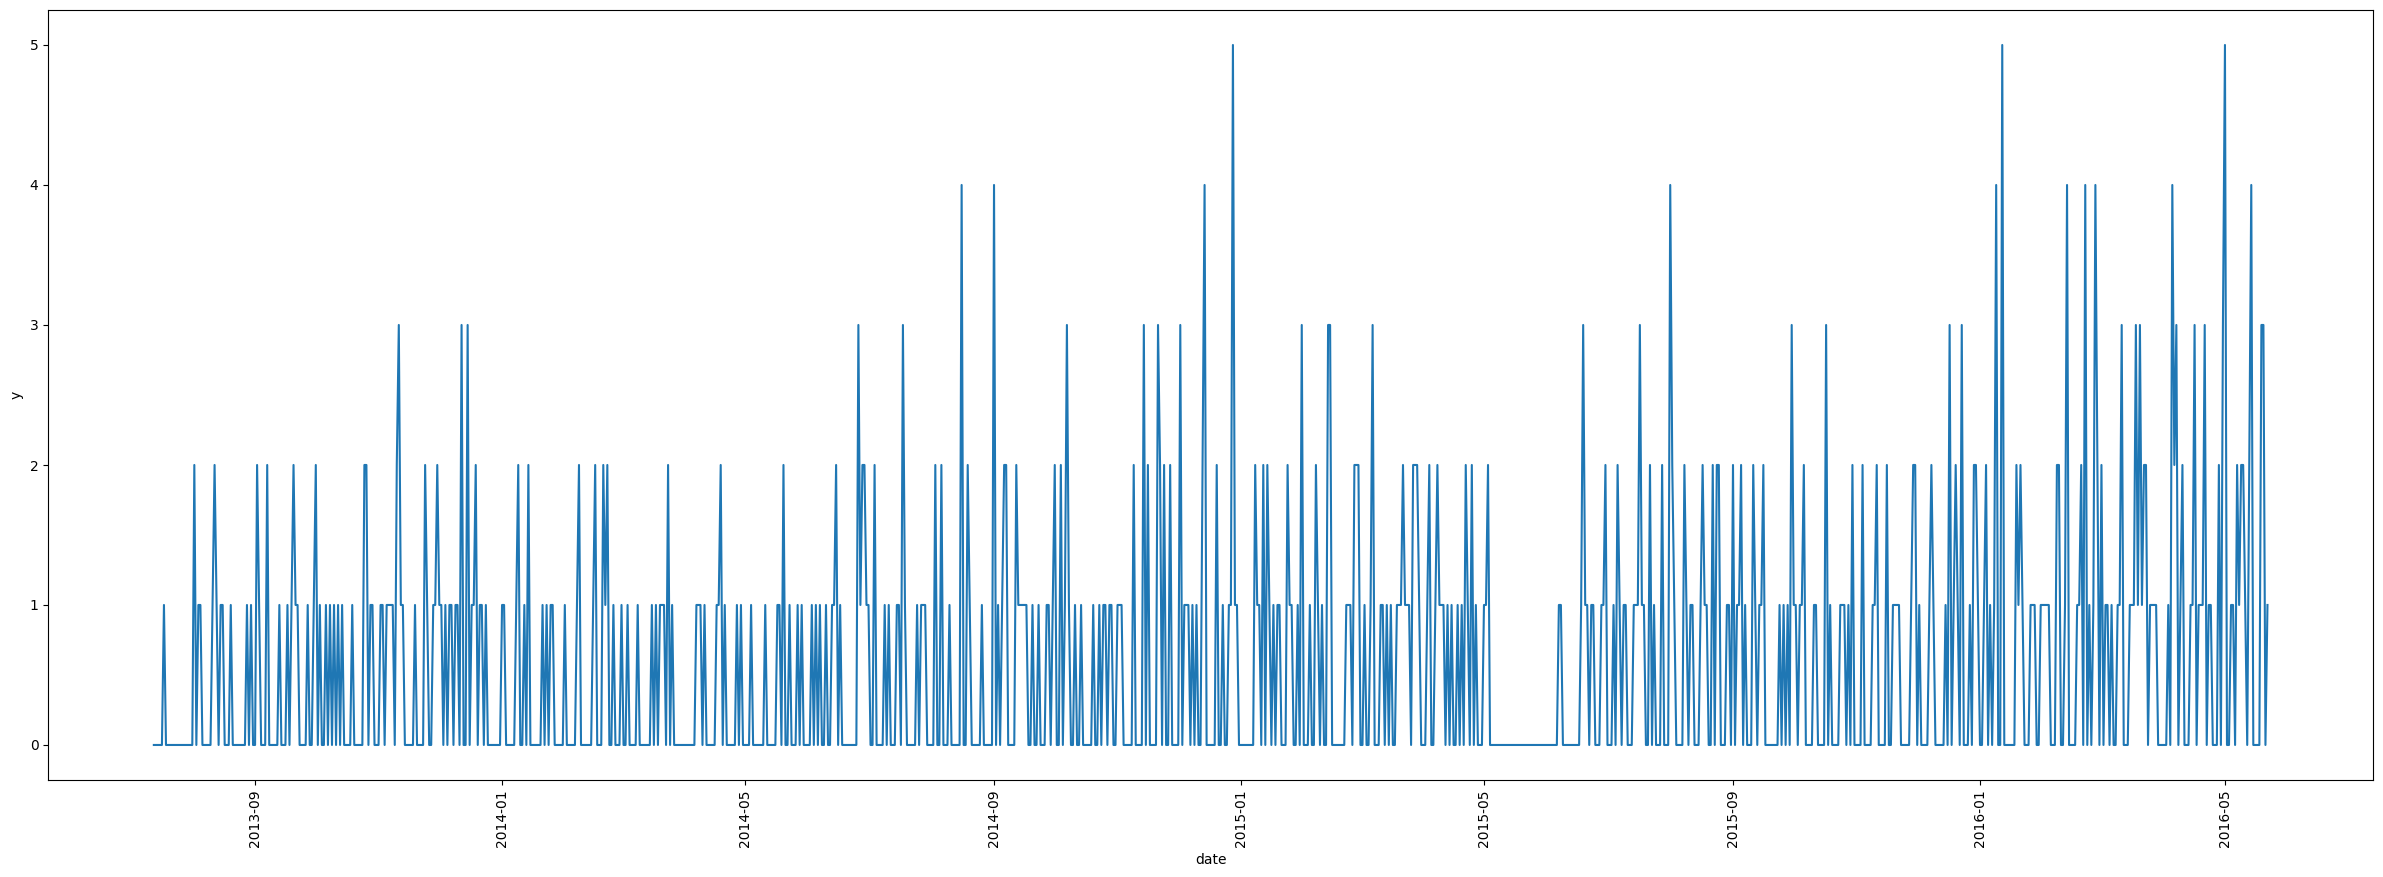

In [138]:
plt.figure(figsize=(30,10))
sns.lineplot(data=data[data['id'] == 'HOBBIES_1_001_CA_1_evaluation'][['date', 'y']], x='date', y = 'y')
plt.xticks(rotation = 90);

In [139]:
data.head()

,id,item_id,d,y,date,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,...,dept_sold_avg,cat_dept_sold_avg,store_item_sold_avg,cat_item_sold_avg,dept_item_sold_avg,state_store_sold_avg,state_store_cat_sold_avg,store_cat_dept_sold_avg,rolling_sold_mean,expanding_sold_mean
16838178,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,897,0,2013-07-13,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,NaN
16838179,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,898,0,2013-07-14,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.0
16838180,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,899,0,2013-07-15,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.0
16838181,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,900,0,2013-07-16,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.0
16838182,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,901,0,2013-07-17,no_event,no_event,no_event,no_event,0,...,0.865234,0.865234,0.605957,0.411133,0.411133,1.635742,1.003906,1.259766,NaN,0.0
